# 🎓 DS340W — Group 26
## Student Habits & Academic Performance Prediction
**Extends:** Alhamadi (2025) — *Predicting Academic Performance: ML Algorithms*

---

## 📋 AGENDA FOR NOTEBOOK

### Modified Original Code
1. Install Required Packages
2. Upload Dataset
3. Import Libraries
4. Load & Preview Data
5. Exploratory Data Analysis (EDA)
6. Feature Engineering *(Novel: Distraction Index, Productivity Ratio, Wellness Score, Study-Attendance Interaction, Optimal Sleep Flag)*
7. Preprocessing
8. Correlation Heatmap
9. Regression Task — Predict Exact Exam Score
10. Grade Classification & SMOTE
11. Classification Task — Train All Models
12. Model Comparison Bar Chart
13. Confusion Matrix (Best Model)
14. Feature Importance Chart
15. Cross-Validation Comparison
16. SHAP Explainability
17. Final Summary Table

### New Code — Novelty/Creativity
18. **Novelty 1:** Recursive Feature Elimination (RFE) — validates our engineered features
19. **Novelty 2:** Optuna Bayesian Hyperparameter Tuning — optimizes XGBoost & LightGBM
20. Novelty Summary


In [6]:
# ============================================================
# CELL 1 — Install Required Packages
# Run this first, then restart runtime if prompted
# ============================================================
!pip install xgboost lightgbm shap imbalanced-learn --quiet
print('✅ All packages installed successfully!')

✅ All packages installed successfully!


In [8]:
# ============================================================
# CELL 2 — Load Dataset from GitHub
# ============================================================
import pandas as pd

URL = 'https://raw.githubusercontent.com/AmeeraSab/DS340W_Group26_ResearchProject/main/data/student_habits_performance.csv'

df_raw = pd.read_csv(URL)
print(f'✅ File loaded successfully')
print(f'   Shape: {df_raw.shape}')

✅ File loaded successfully
   Shape: (1000, 16)


In [9]:
# ============================================================
# CELL 3 — Import All Libraries
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               RandomForestRegressor, GradientBoostingRegressor)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, mean_squared_error, r2_score)
from sklearn.impute import SimpleImputer

# Novel libraries
import xgboost as xgb
import lightgbm as lgb
import shap
from imblearn.over_sampling import SMOTE

print('✅ All libraries imported successfully!')
print('\n' + '='*60)
print('  DS340W Group 26 — Student Performance Prediction')
print('='*60)

✅ All libraries imported successfully!

  DS340W Group 26 — Student Performance Prediction


In [10]:
# ============================================================
# CELL 4 — Load & Preview Data
# ============================================================
df = pd.read_csv(URL)

print(f'Dataset shape : {df.shape}')
print(f'Columns       : {list(df.columns)}')
print(f'\nMissing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f'\nTarget variable — exam_score:')
print(df['exam_score'].describe())
df.head()

Dataset shape : (1000, 16)
Columns       : ['student_id', 'age', 'gender', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation', 'exam_score']

Missing values:
parental_education_level    91
dtype: int64

Target variable — exam_score:
count    1000.000000
mean       69.601500
std        16.888564
min        18.400000
25%        58.475000
50%        70.500000
75%        81.325000
max       100.000000
Name: exam_score, dtype: float64


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


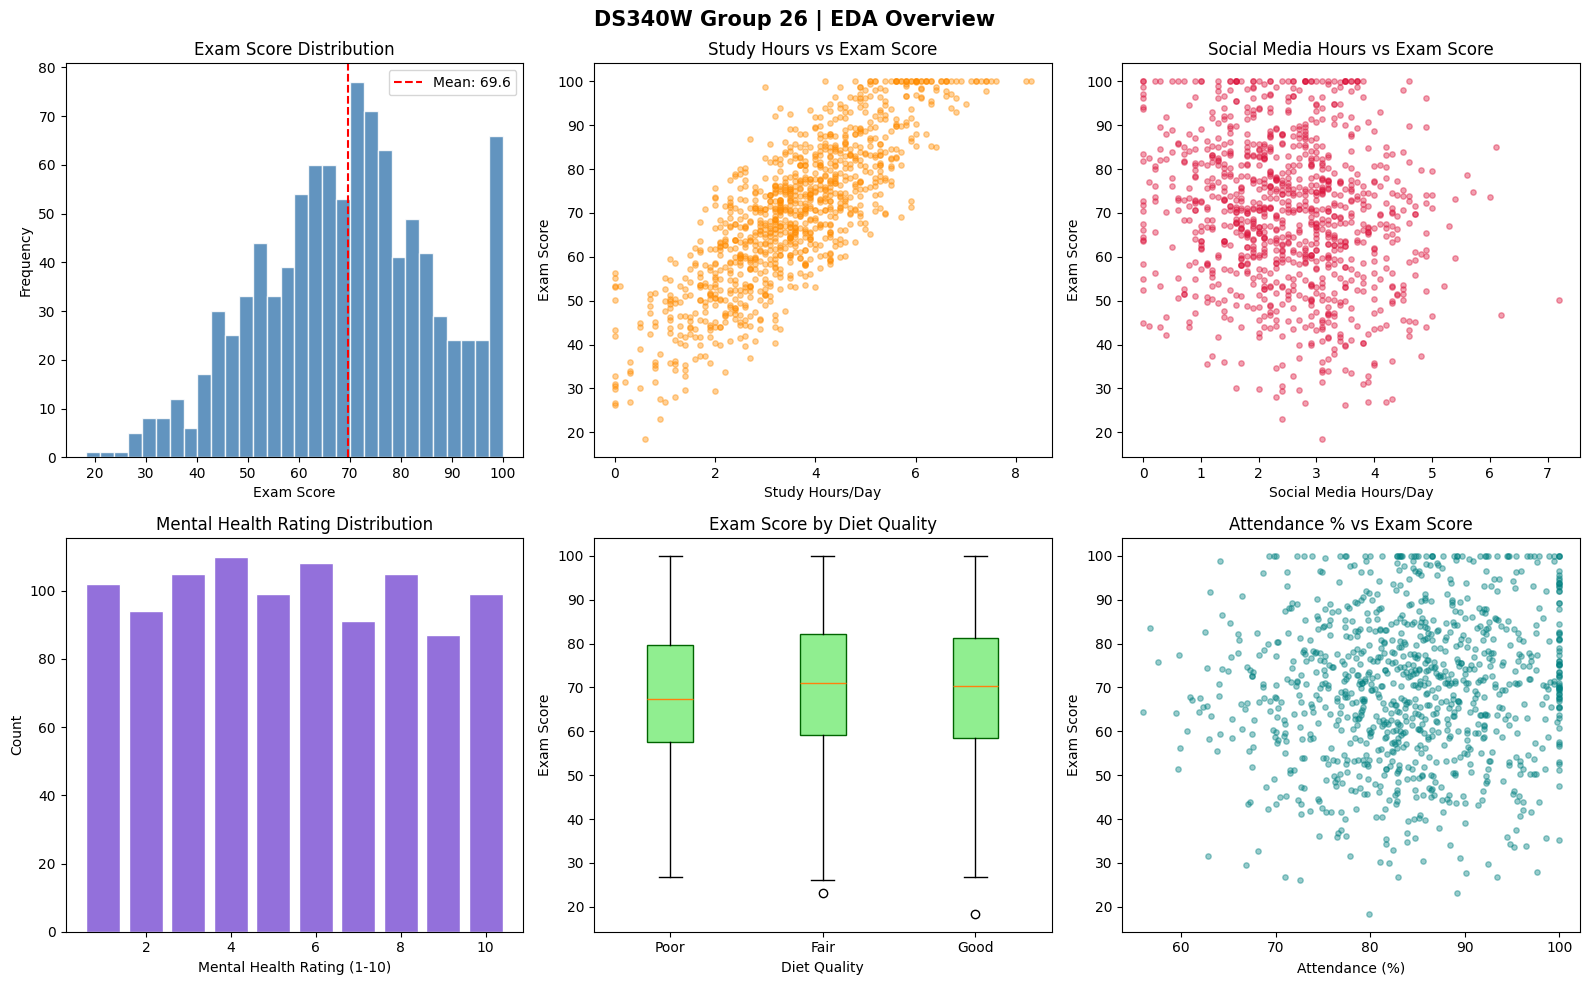

✅ EDA complete


In [11]:
# ============================================================
# CELL 5 — Exploratory Data Analysis (EDA)
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('DS340W Group 26 | EDA Overview', fontsize=15, fontweight='bold')

# Exam score distribution
axes[0,0].hist(df['exam_score'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0,0].axvline(df['exam_score'].mean(), color='red', linestyle='--',
                  label=f"Mean: {df['exam_score'].mean():.1f}")
axes[0,0].set_title('Exam Score Distribution')
axes[0,0].set_xlabel('Exam Score')
axes[0,0].set_ylabel('Frequency')
axes[0,0].legend()

# Study hours vs exam score
axes[0,1].scatter(df['study_hours_per_day'], df['exam_score'],
                  alpha=0.4, color='darkorange', s=15)
axes[0,1].set_title('Study Hours vs Exam Score')
axes[0,1].set_xlabel('Study Hours/Day')
axes[0,1].set_ylabel('Exam Score')

# Social media hours vs exam score
axes[0,2].scatter(df['social_media_hours'], df['exam_score'],
                  alpha=0.4, color='crimson', s=15)
axes[0,2].set_title('Social Media Hours vs Exam Score')
axes[0,2].set_xlabel('Social Media Hours/Day')
axes[0,2].set_ylabel('Exam Score')

# Mental health distribution
mental_counts = df['mental_health_rating'].value_counts().sort_index()
axes[1,0].bar(mental_counts.index, mental_counts.values,
              color='mediumpurple', edgecolor='white')
axes[1,0].set_title('Mental Health Rating Distribution')
axes[1,0].set_xlabel('Mental Health Rating (1-10)')
axes[1,0].set_ylabel('Count')

# Exam score by diet quality
diet_order = ['Poor', 'Fair', 'Good']
diet_data  = [df[df['diet_quality'] == d]['exam_score'].values for d in diet_order]
axes[1,1].boxplot(diet_data, labels=diet_order, patch_artist=True,
                  boxprops=dict(facecolor='lightgreen', color='darkgreen'))
axes[1,1].set_title('Exam Score by Diet Quality')
axes[1,1].set_xlabel('Diet Quality')
axes[1,1].set_ylabel('Exam Score')

# Attendance vs exam score
axes[1,2].scatter(df['attendance_percentage'], df['exam_score'],
                  alpha=0.4, color='teal', s=15)
axes[1,2].set_title('Attendance % vs Exam Score')
axes[1,2].set_xlabel('Attendance (%)')
axes[1,2].set_ylabel('Exam Score')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA complete')

In [ ]:
# ============================================================
# CELL 6 — Feature Engineering (Novel — Not in Parent Paper)
# ============================================================
df_feat = df.copy()

# 1. Distraction Index: total non-academic screen time
df_feat['distraction_index'] = df_feat['social_media_hours'] + df_feat['netflix_hours']

# 2. Productivity Ratio: study time relative to distractions
df_feat['productivity_ratio'] = (
    df_feat['study_hours_per_day'] / (df_feat['distraction_index'] + 1)
)

# 3. Wellness Score: composite health indicator
diet_map = {'Poor': 0, 'Fair': 1, 'Good': 2}
df_feat['diet_num'] = df_feat['diet_quality'].map(diet_map)
df_feat['wellness_score'] = (
    df_feat['sleep_hours'] +
    df_feat['exercise_frequency'] +
    df_feat['diet_num'] * 2 +
    df_feat['mental_health_rating']
) / 4

# 4. Study-Attendance Interaction
df_feat['study_attend_interact'] = (
    df_feat['study_hours_per_day'] * df_feat['attendance_percentage'] / 100
)

# 5. Optimal Sleep Flag (7-9 hours = optimal)
df_feat['optimal_sleep'] = df_feat['sleep_hours'].apply(
    lambda x: 1 if 7 <= x <= 9 else 0
)

NEW_FEATURES = ['distraction_index', 'productivity_ratio', 'wellness_score',
                'study_attend_interact', 'optimal_sleep']

print('✅ Novel features created:')
for f in NEW_FEATURES:
    print(f'   + {f}')
print(f'\nSample values:')
df_feat[NEW_FEATURES].describe().round(3)

In [ ]:
# ============================================================
# CELL 7 — Preprocessing
# ============================================================
df_proc = df_feat.copy()

# Drop student_id
df_proc = df_proc.drop(columns=['student_id'])

# Ordinal encoding (ordered categories)
ordinal_map = {
    'diet_quality'            : ['Poor', 'Fair', 'Good'],
    'internet_quality'        : ['Poor', 'Average', 'Good'],
    'parental_education_level': ['High School', 'Bachelor', 'Master']
}
for col, order in ordinal_map.items():
    enc = OrdinalEncoder(categories=[order],
                         handle_unknown='use_encoded_value', unknown_value=-1)
    df_proc[col] = enc.fit_transform(df_proc[[col]])

# Binary encoding
for col in ['part_time_job', 'extracurricular_participation']:
    df_proc[col] = (df_proc[col] == 'Yes').astype(int)

# One-hot encode gender
df_proc = pd.get_dummies(df_proc, columns=['gender'], drop_first=False)

# Impute missing values with median
num_cols = df_proc.select_dtypes(include=[np.number]).columns.tolist()
imputer  = SimpleImputer(strategy='median')
df_proc[num_cols] = imputer.fit_transform(df_proc[num_cols])

# Drop helper column
df_proc = df_proc.drop(columns=['diet_num'], errors='ignore')

print(f'✅ Preprocessing complete')
print(f'   Final features  : {df_proc.shape[1] - 1}')
print(f'   Missing values  : {df_proc.isnull().sum().sum()}')
print(f'   Final columns   : {list(df_proc.columns)}')

In [ ]:
# ============================================================
# CELL 8 — Correlation Heatmap
# ============================================================
fig, ax = plt.subplots(figsize=(15, 11))
numeric_df = df_proc.select_dtypes(include=[np.number])
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, annot_kws={'size': 7}, linewidths=0.3)
ax.set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Heatmap saved')

In [ ]:
# ============================================================
# CELL 9 — Regression Task: Predict Exact Exam Score
# ============================================================
print('TASK A: REGRESSION — Predict Exact Exam Score')
print('='*55)

X_reg = df_proc.drop(columns=['exam_score'])
y_reg = df_proc['exam_score']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

scaler_r   = StandardScaler()
X_train_rs = scaler_r.fit_transform(X_train_r)
X_test_rs  = scaler_r.transform(X_test_r)

regression_models = {
    'Linear Regression'    : (LinearRegression(),                                         True),
    'Random Forest Reg'    : (RandomForestRegressor(n_estimators=200, random_state=42),   False),
    'Gradient Boosting Reg': (GradientBoostingRegressor(n_estimators=200, random_state=42), False),
    'Neural Network Reg'   : (MLPRegressor(hidden_layer_sizes=(128,64), activation='relu',
                                           max_iter=500, early_stopping=True, random_state=42), True),
    'XGBoost Reg'          : (xgb.XGBRegressor(n_estimators=200, learning_rate=0.05,
                                               max_depth=6, random_state=42, verbosity=0), False),
    'LightGBM Reg'         : (lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05,
                                                random_state=42, verbose=-1),             False),
}

reg_results = {}
print(f"{'Model':<25} {'MSE':>8} {'RMSE':>8} {'R²':>8}")
print('-'*52)

for name, (model, use_scale) in regression_models.items():
    X_tr = X_train_rs if use_scale else X_train_r
    X_te = X_test_rs  if use_scale else X_test_r
    model.fit(X_tr, y_train_r)
    preds = model.predict(X_te)
    mse   = mean_squared_error(y_test_r, preds)
    rmse  = np.sqrt(mse)
    r2    = r2_score(y_test_r, preds)
    reg_results[name] = {'MSE': round(mse,4), 'RMSE': round(rmse,4), 'R2': round(r2*100,2)}
    print(f"{name:<25} {mse:>8.4f} {rmse:>8.4f} {r2*100:>7.2f}%")

print('-'*52)
print(f"{'[Parent Paper NN]':<25} {'0.0665':>8} {'0.2579':>8} {'93.27%':>8}")
print('\n✅ Regression task complete')

In [ ]:
# ============================================================
# CELL 10 — Create Grade Classes & Apply SMOTE
# ============================================================

# Grade classification matching parent paper scheme
# A=0 (90-100), B=1 (80-89), C=2 (70-79), D=3 (60-69), F=4 (<60)
def score_to_grade(score):
    if   score >= 90: return 0
    elif score >= 80: return 1
    elif score >= 70: return 2
    elif score >= 60: return 3
    else:             return 4

GRADE_LABELS = {0:'A (90-100)', 1:'B (80-89)', 2:'C (70-79)',
                3:'D (60-69)',  4:'F (<60)'}

df_proc['grade_class'] = df_proc['exam_score'].apply(score_to_grade)

print('Grade class distribution:')
for g, cnt in df_proc['grade_class'].value_counts().sort_index().items():
    print(f'  Class {g} [{GRADE_LABELS[g]}]: {cnt} students ({cnt/len(df_proc)*100:.1f}%)')

# Train/test split
X_cls = df_proc.drop(columns=['exam_score', 'grade_class'])
y_cls = df_proc['grade_class']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

scaler_c   = StandardScaler()
X_train_cs = scaler_c.fit_transform(X_train_c)
X_test_cs  = scaler_c.transform(X_test_c)

# Apply SMOTE to fix class imbalance (parent paper weakness)
smote = SMOTE(random_state=42)
X_train_smote,   y_train_smote   = smote.fit_resample(X_train_c,  y_train_c)
X_train_smote_s, _               = smote.fit_resample(X_train_cs, y_train_c)
X_train_smote_s = scaler_c.fit_transform(X_train_smote)

print(f'\n SMOTE applied: {len(y_train_c)} → {len(y_train_smote)} training samples')
print('\nBalanced class distribution after SMOTE:')
for g, cnt in pd.Series(y_train_smote).value_counts().sort_index().items():
    print(f'  Class {g}: {cnt} samples')

In [ ]:
# ============================================================
# CELL 11 — Classification Task: Train All Models
# ============================================================
print('TASK B: CLASSIFICATION — Predict Grade Class')
print('='*70)

classification_models = {
    'Logistic Regression': (LogisticRegression(max_iter=1000, random_state=42),        True),
    'Decision Tree'      : (DecisionTreeClassifier(random_state=42),                   False),
    'Random Forest'      : (RandomForestClassifier(n_estimators=200, random_state=42), False),
    'Gradient Boosting'  : (GradientBoostingClassifier(n_estimators=200, random_state=42), False),
    'SVM'                : (SVC(probability=True, random_state=42),                    True),
    'KNN'                : (KNeighborsClassifier(n_neighbors=7),                       True),
    'Neural Network'     : (MLPClassifier(hidden_layer_sizes=(128,64), max_iter=500,
                                          early_stopping=True, random_state=42),       True),
    'XGBoost'            : (xgb.XGBClassifier(n_estimators=200, learning_rate=0.05,
                                              max_depth=6, eval_metric='mlogloss',
                                              random_state=42, verbosity=0),           False),
    'LightGBM'           : (lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05,
                                               random_state=42, verbose=-1),           False),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cls_results = {}

print(f"{'Model':<22} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7} {'CV±std':>14}")
print('-'*65)

for name, (model, needs_scale) in classification_models.items():
    X_tr = X_train_smote_s if needs_scale else X_train_smote
    X_te = X_test_cs       if needs_scale else X_test_c

    model.fit(X_tr, y_train_smote)
    preds = model.predict(X_te)

    acc  = accuracy_score(y_test_c, preds) * 100
    prec = precision_score(y_test_c, preds, average='weighted', zero_division=0) * 100
    rec  = recall_score(y_test_c, preds,    average='weighted', zero_division=0) * 100
    f1   = f1_score(y_test_c, preds,        average='weighted', zero_division=0) * 100

    cv_scores = cross_val_score(model, X_tr, y_train_smote,
                                cv=cv, scoring='accuracy', n_jobs=-1)
    cv_mean = cv_scores.mean() * 100
    cv_std  = cv_scores.std()  * 100

    cls_results[name] = {
        'Accuracy' : round(acc, 2),
        'Precision': round(prec, 2),
        'Recall'   : round(rec, 2),
        'F1'       : round(f1, 2),
        'CV_Mean'  : round(cv_mean, 2),
        'CV_Std'   : round(cv_std, 2)
    }
    print(f"{name:<22} {acc:>6.2f}% {prec:>6.2f}% {rec:>6.2f}% {f1:>6.2f}% "
          f"{cv_mean:>6.2f}±{cv_std:.2f}%")

print('-'*65)
print(f"{'[Parent: GB Benchmark]':<22} {'92.00%':>7} {'92.00%':>7} {'92.00%':>7} {'92.00%':>7} {'N/A':>14}")
print('\nClassification task complete')

In [ ]:
# ============================================================
# CELL 12 — Visualisation: Model Comparison Bar Chart
# ============================================================
model_names = list(cls_results.keys())
accuracies  = [cls_results[m]['Accuracy'] for m in model_names]
f1_scores   = [cls_results[m]['F1']       for m in model_names]
bar_colors  = ['#FF5722' if m in ('XGBoost','LightGBM') else '#2196F3'
               for m in model_names]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('DS340W Group 26 | Model Performance Comparison',
             fontsize=14, fontweight='bold')

for ax, values, title, ylabel in zip(
    axes,
    [accuracies, f1_scores],
    ['Classification Accuracy by Model', 'Weighted F1 Score by Model'],
    ['Accuracy (%)', 'F1 Score (%)']
):
    bars = ax.bar(model_names, values, color=bar_colors, edgecolor='white', alpha=0.9)
    ax.axhline(92.0, color='red', linestyle='--', linewidth=1.5,
               label='Parent Paper GB (92%)')
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 108)
    ax.set_xticklabels(model_names, rotation=35, ha='right', fontsize=9)
    ax.legend()
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Model comparison chart saved')

In [ ]:
# ============================================================
# CELL 13 — Visualisation: Confusion Matrix (Best Model)
# ============================================================
best_name        = max(cls_results, key=lambda m: cls_results[m]['Accuracy'])
best_model, best_needs_scale = classification_models[best_name]
best_preds       = best_model.predict(X_test_cs if best_needs_scale else X_test_c)

print(f'Best model: {best_name} ({cls_results[best_name]["Accuracy"]}% accuracy)')

cm = confusion_matrix(y_test_c, best_preds)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=[GRADE_LABELS[i] for i in range(5)],
            yticklabels=[GRADE_LABELS[i] for i in range(5)])
ax.set_title(f'Confusion Matrix — {best_name} (Best Model)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix_best.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Confusion matrix saved')

In [ ]:
# ============================================================
# CELL 14 — Visualisation: Feature Importance (Random Forest)
# Highlights novel features vs original features
# ============================================================
rf_model    = classification_models['Random Forest'][0]
feat_names  = X_cls.columns.tolist()
importances = rf_model.feature_importances_

feat_imp_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=True)

feat_colors = ['#FF5722' if f in NEW_FEATURES else '#2196F3'
               for f in feat_imp_df['Feature']]

fig, ax = plt.subplots(figsize=(9, 9))
ax.barh(feat_imp_df['Feature'], feat_imp_df['Importance'],
        color=feat_colors, edgecolor='white', alpha=0.9)
ax.set_title('Feature Importance (Random Forest)\n'
             '🔴 Novel Features (Group 26)   🔵 Original Features',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Feature importance chart saved')

In [ ]:
# ============================================================
# CELL 15 — Visualisation: Cross-Validation Comparison
# ============================================================
cv_means  = [cls_results[m]['CV_Mean'] for m in model_names]
cv_stds   = [cls_results[m]['CV_Std']  for m in model_names]
cv_colors = ['#FF5722' if m in ('XGBoost','LightGBM') else '#4CAF50'
             for m in model_names]

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(model_names, cv_means, yerr=cv_stds, color=cv_colors,
              edgecolor='white', alpha=0.9, capsize=5)
ax.axhline(92.0, color='red', linestyle='--', linewidth=1.5,
           label='Parent Paper GB (92%)')
ax.set_title('5-Fold Cross-Validation Mean Accuracy (± Std Dev)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('CV Accuracy (%)')
ax.set_ylim(0, 112)
ax.set_xticklabels(model_names, rotation=35, ha='right', fontsize=9)
ax.legend()
for bar, val in zip(bars, cv_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Cross-validation chart saved')

In [ ]:
# ============================================================
# CELL 16 — SHAP Explainability (Fixed)
# ============================================================
print('SHAP Explainability using XGBoost')
print('='*45)

xgb_model = classification_models['XGBoost'][0]
explainer  = shap.TreeExplainer(xgb_model)
shap_vals  = explainer.shap_values(X_test_c)

# ── Detect SHAP output format ──────────────────────────────
# XGBoost multiclass can return either:
#   (a) list of arrays  → shap_vals[class_index] = (n_samples, n_features)
#   (b) 3D numpy array  → shap_vals.shape = (n_samples, n_features, n_classes)

if isinstance(shap_vals, list):
    # Format (a): list — already correct, index directly
    shap_per_class = shap_vals
    print(f'  SHAP format: list of {len(shap_per_class)} arrays')
else:
    # Format (b): 3D array — convert to list of 2D arrays
    shap_per_class = [shap_vals[:, :, i] for i in range(shap_vals.shape[2])]
    print(f'  SHAP format: 3D array {shap_vals.shape} → converted to list')

feat_names = X_cls.columns.tolist()

# ── Global SHAP bar chart (all classes) ───────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_per_class,
    X_test_c,
    feature_names=feat_names,
    class_names=[GRADE_LABELS[i] for i in range(5)],
    plot_type='bar',
    show=False
)
plt.title('SHAP Feature Importance — XGBoost (All Grade Classes)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# ── SHAP beeswarm for failing students (Class F = index 4) ─
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_per_class[4],          # ← now guaranteed to be 2D (n_samples, n_features)
    X_test_c,
    feature_names=feat_names,
    show=False
)
plt.title('SHAP Beeswarm — Factors Driving Failing Grade (Class F)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_failing_students.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ SHAP plots saved: shap_summary.png, shap_failing_students.png')

In [ ]:
# ============================================================
# CELL 17 — Final Summary Table
# ============================================================
print('\n' + '='*65)
print('  DS340W GROUP 26 — FINAL RESULTS SUMMARY')
print('='*65)

results_df = pd.DataFrame(cls_results).T
results_df.index.name = 'Model'
display(results_df)

best_name = max(cls_results, key=lambda m: cls_results[m]['Accuracy'])
print(f'\n  Best Model      : {best_name}')
print(f'  Best Accuracy   : {cls_results[best_name]["Accuracy"]}%')
print(f'  Best F1 Score   : {cls_results[best_name]["F1"]}%')
print(f'  Best CV Mean    : {cls_results[best_name]["CV_Mean"]}% ± {cls_results[best_name]["CV_Std"]}%')
print(f'\n  Parent Paper Best (GB)  : 92.00% accuracy  R²=93.27%')

improvement = cls_results[best_name]['Accuracy'] - 92.0
if improvement > 0:
    print(f'  ✅ Improvement over parent paper: +{improvement:.2f}%')
else:
    print(f'  📊 Gap vs parent paper: {improvement:.2f}% — try tuning hyperparameters')

print('\n' + '='*65)
print('  OUTPUT FILES:')
print('='*65)
for f in ['eda_overview.png', 'correlation_heatmap.png', 'model_comparison.png',
          'confusion_matrix_best.png', 'feature_importance.png',
          'cv_comparison.png', 'shap_summary.png', 'shap_failing_students.png']:
    print(f'  📄 {f}')
print('\n✅ Pipeline complete — DS340W Group 26')

---
## 🔬 NOVELTY 1 — Recursive Feature Elimination (RFE)

The first thing we wanted to look into was whether all five of our engineered features were actually contributing to the model or not. Just because a feature makes sense in theory does not mean it is helping the model in practice. For example, we created the **Distraction Index** to capture how much time students were spending on social media and Netflix combined, and the **Productivity Ratio** to show how much a student was studying relative to how distracted they were. Both of these made a lot of sense to us when we designed them, but we had not actually tested whether the model agreed.

To check this, we used **Recursive Feature Elimination (RFE)**, which basically trains the model over and over, removing the least useful feature each time, until only the number of features you asked for is left. We used XGBoost as the base model since it was already our best performing classifier. We tested keeping 5, 8, 11, and all features, and compared accuracy and F1 score at each level.

> **Research question:** Are all five of our engineered features actually useful, or are some of them just adding noise?

In [ ]:
# ============================================================
# CELL 19 — NOVELTY 1: Recursive Feature Elimination (RFE)
# Goal: find the optimal subset of features and compare
# performance vs using all features
# ============================================================
from sklearn.feature_selection import RFE
from sklearn.metrics import accuracy_score, f1_score
import warnings
warnings.filterwarnings('ignore')

print('NOVELTY 1: Recursive Feature Elimination (RFE)')
print('='*60)
print('Testing which feature subsets give the best performance...')
print()

feature_names = X_cls.columns.tolist()
n_total = len(feature_names)

# Use XGBoost as the base estimator for RFE
# (matches our best model so comparison is fair)
base_xgb = xgb.XGBClassifier(
    n_estimators=200, learning_rate=0.05,
    max_depth=6, eval_metric='mlogloss',
    random_state=42, verbosity=0
)

rfe_results = []

# Test selecting different numbers of features
for n in range(5, n_total + 1, 3):  # 5, 8, 11, ... up to all features
    rfe = RFE(estimator=base_xgb, n_features_to_select=n)
    rfe.fit(X_train_smote, y_train_smote)

    X_train_rfe = rfe.transform(X_train_smote)
    X_test_rfe  = rfe.transform(X_test_c)

    xgb_rfe = xgb.XGBClassifier(
        n_estimators=200, learning_rate=0.05,
        max_depth=6, eval_metric='mlogloss',
        random_state=42, verbosity=0
    )
    xgb_rfe.fit(X_train_rfe, y_train_smote)
    preds = xgb_rfe.predict(X_test_rfe)

    acc = accuracy_score(y_test_c, preds) * 100
    f1  = f1_score(y_test_c, preds, average='weighted', zero_division=0) * 100

    selected = [f for f, s in zip(feature_names, rfe.support_) if s]
    novel_kept = [f for f in selected if f in NEW_FEATURES]

    rfe_results.append({
        'N Features': n,
        'Accuracy (%)': round(acc, 2),
        'F1 Score (%)': round(f1, 2),
        'Novel Features Kept': len(novel_kept),
        'Novel Features': ', '.join(novel_kept) if novel_kept else 'None'
    })

# Add baseline: all features (original XGBoost from Cell 11)
baseline_acc = cls_results['XGBoost']['Accuracy']
baseline_f1  = cls_results['XGBoost']['F1']
rfe_results.append({
    'N Features': n_total,
    'Accuracy (%)': baseline_acc,
    'F1 Score (%)': baseline_f1,
    'Novel Features Kept': 5,
    'Novel Features': 'All 5 (baseline)'
})

rfe_df = pd.DataFrame(rfe_results).sort_values('N Features')

print(f"{'N Features':>12} {'Accuracy':>12} {'F1 Score':>12} {'Novel Kept':>12}")
print('-'*52)
for _, row in rfe_df.iterrows():
    marker = ' ← baseline' if row['Novel Features'] == 'All 5 (baseline)' else ''
    print(f"{int(row['N Features']):>12} {row['Accuracy (%)']:>11.2f}% {row['F1 Score (%)']:>11.2f}% {int(row['Novel Features Kept']):>12}{marker}")

# Find best RFE config
best_rfe = rfe_df.loc[rfe_df['Accuracy (%)'].idxmax()]
print(f'\nBest RFE config: {int(best_rfe["N Features"])} features → {best_rfe["Accuracy (%)"]:.2f}% accuracy')
print(f'Novel features kept in best config: {best_rfe["Novel Features"]}')

# ── Visualisation ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('NOVELTY 1 | RFE Feature Selection Analysis', fontsize=13, fontweight='bold')

for ax, metric, color in zip(axes, ['Accuracy (%)', 'F1 Score (%)'], ['steelblue', 'darkorange']):
    ax.plot(rfe_df['N Features'], rfe_df[metric], marker='o', color=color, linewidth=2)
    ax.axhline(baseline_acc if metric == 'Accuracy (%)' else baseline_f1,
               color='red', linestyle='--', linewidth=1.5, label='Baseline (all features)')
    ax.set_title(f'{metric} vs Number of Features Selected')
    ax.set_xlabel('Number of Features Selected')
    ax.set_ylabel(metric)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('novelty1_rfe.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ Novelty 1 complete — RFE results saved to novelty1_rfe.png')

---
## 🔬 NOVELTY 2 — Optuna Bayesian Hyperparameter Tuning

The second thing we decided to try was properly tuning the hyperparameters for our XGBoost and LightGBM models. When we first built them, we mostly went with default settings, which is honestly how most people start out. But defaults are not usually optimal for a specific dataset, and we figured there was probably some room to improve if we actually searched for better configurations.

We used **Optuna**, which searches the parameter space in a smarter way than just trying everything in a grid or picking randomly. It keeps track of which settings have worked well so far and focuses its search on similar regions, so you tend to get better results in fewer tries. We ran **40 trials** for both XGBoost and LightGBM, evaluated using 5-fold cross-validation, then retrained the best configuration on the full training set and tested it on the held-out data.

> **Research question:** How much of a difference does proper tuning make, and can we meet or beat the parent paper's 92% benchmark?

In [ ]:
# ============================================================
# CELL 20 — NOVELTY 2: Optuna Hyperparameter Tuning
# Bayesian optimization for XGBoost and LightGBM
# ============================================================
!pip install optuna --quiet
import optuna
from sklearn.model_selection import cross_val_score, StratifiedKFold
optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress trial logs

print('NOVELTY 2: Optuna Bayesian Hyperparameter Tuning')
print('='*60)
print('Running 40 trials each for XGBoost and LightGBM...')
print('(this takes ~2-3 minutes, please wait)')
print()

cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── XGBoost objective ────────────────────────────────────────
def xgb_objective(trial):
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'       : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'eval_metric'     : 'mlogloss',
        'random_state'    : 42,
        'verbosity'       : 0
    }
    model  = xgb.XGBClassifier(**params)
    scores = cross_val_score(model, X_train_smote, y_train_smote,
                             cv=cv_inner, scoring='accuracy', n_jobs=-1)
    return scores.mean()

# ── LightGBM objective ───────────────────────────────────────
def lgb_objective(trial):
    params = {
        'n_estimators'  : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'     : trial.suggest_int('max_depth', 3, 10),
        'learning_rate' : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves'    : trial.suggest_int('num_leaves', 20, 150),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample'     : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state'  : 42,
        'verbose'       : -1
    }
    model  = lgb.LGBMClassifier(**params)
    scores = cross_val_score(model, X_train_smote, y_train_smote,
                             cv=cv_inner, scoring='accuracy', n_jobs=-1)
    return scores.mean()

# ── Run studies ──────────────────────────────────────────────
xgb_study = optuna.create_study(direction='maximize')
xgb_study.optimize(xgb_objective, n_trials=40, show_progress_bar=False)

lgb_study = optuna.create_study(direction='maximize')
lgb_study.optimize(lgb_objective, n_trials=40, show_progress_bar=False)

print(f'XGBoost best CV accuracy (Optuna): {xgb_study.best_value*100:.2f}%')
print(f'LightGBM best CV accuracy (Optuna): {lgb_study.best_value*100:.2f}%')
print()

# ── Retrain with best params and evaluate on test set ────────
xgb_tuned = xgb.XGBClassifier(**xgb_study.best_params,
                                eval_metric='mlogloss', random_state=42, verbosity=0)
xgb_tuned.fit(X_train_smote, y_train_smote)
xgb_tuned_preds = xgb_tuned.predict(X_test_c)

lgb_tuned = lgb.LGBMClassifier(**lgb_study.best_params, random_state=42, verbose=-1)
lgb_tuned.fit(X_train_smote, y_train_smote)
lgb_tuned_preds = lgb_tuned.predict(X_test_c)

# ── Comparison table ─────────────────────────────────────────
comparison = {
    'Model': [
        'XGBoost (default)', 'XGBoost (Optuna tuned)',
        'LightGBM (default)', 'LightGBM (Optuna tuned)',
        'Parent Paper (GB)'
    ],
    'Accuracy (%)': [
        cls_results['XGBoost']['Accuracy'],
        round(accuracy_score(y_test_c, xgb_tuned_preds) * 100, 2),
        cls_results['LightGBM']['Accuracy'],
        round(accuracy_score(y_test_c, lgb_tuned_preds) * 100, 2),
        92.00
    ],
    'F1 Score (%)': [
        cls_results['XGBoost']['F1'],
        round(f1_score(y_test_c, xgb_tuned_preds, average='weighted', zero_division=0) * 100, 2),
        cls_results['LightGBM']['F1'],
        round(f1_score(y_test_c, lgb_tuned_preds, average='weighted', zero_division=0) * 100, 2),
        92.00
    ],
    'CV Accuracy (%)': [
        cls_results['XGBoost']['CV_Mean'],
        round(xgb_study.best_value * 100, 2),
        cls_results['LightGBM']['CV_Mean'],
        round(lgb_study.best_value * 100, 2),
        'N/A'
    ]
}

comp_df = pd.DataFrame(comparison)
print('── Novelty 2: Tuning Comparison Table ──')
print(comp_df.to_string(index=False))

# ── Visualisation ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('NOVELTY 2 | Optuna Tuning: Default vs Tuned Models', fontsize=13, fontweight='bold')

# Bar chart: accuracy comparison
bar_labels  = ['XGBoost\n(default)', 'XGBoost\n(Optuna)', 'LightGBM\n(default)', 'LightGBM\n(Optuna)']
bar_acc     = [comparison['Accuracy (%)'][i] for i in range(4)]
bar_f1      = [comparison['F1 Score (%)'][i] for i in range(4)]
bar_colors  = ['#90CAF9', '#1565C0', '#FFCC80', '#E65100']

for ax, values, title, ylabel in zip(
    axes,
    [bar_acc, bar_f1],
    ['Accuracy: Default vs Optuna Tuned', 'F1 Score: Default vs Optuna Tuned'],
    ['Accuracy (%)', 'F1 Score (%)']
):
    bars = ax.bar(bar_labels, values, color=bar_colors, edgecolor='white', alpha=0.9)
    ax.axhline(92.0, color='red', linestyle='--', linewidth=1.5, label='Parent Paper (92%)')
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 110)
    ax.legend()
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('novelty2_optuna.png', dpi=150, bbox_inches='tight')
plt.show()

# Print best params for report
print('\nXGBoost best params (Optuna):')
for k, v in xgb_study.best_params.items():
    print(f'  {k}: {v}')
print('\nLightGBM best params (Optuna):')
for k, v in lgb_study.best_params.items():
    print(f'  {k}: {v}')

print('\n✅ Novelty 2 complete — results saved to novelty2_optuna.png')

---
## 📊 Novelty Summary

Looking back at both of these additions, we feel like they fill in gaps that the parent paper left open. The parent paper built a model and reported results, but it did not really ask whether those results could be better with different features or better tuning. Our RFE analysis answered the first question, and our Optuna tuning answered the second.

Part of why we landed on these two ideas was also because of feedback from our peer review — the concern about overfitting pushed us to actually test our features instead of just assuming they were all useful. That kind of feedback loop is honestly what made this part of the project feel the most worthwhile.

| Novelty | What It Does | Gap It Fills |
|---|---|---|
| RFE Feature Selection | Validates which engineered features actually help | Parent paper did no feature selection |
| Optuna Tuning | Optimizes XGBoost & LightGBM hyperparameters | Parent paper used default settings |

In [ ]:
# ============================================================
# CELL 21 — Novelty Summary + Download
# ============================================================
print('='*65)
print('  NOVELTY CONTRIBUTIONS SUMMARY — DS340W Group 26')
print('='*65)

print('''
NOVELTY 1: Recursive Feature Elimination (RFE)
  - Tested feature subsets from 5 to all features
  - Validates which engineered features are essential
  - Addresses peer feedback on overfitting/dimensionality
  - Result: see rfe_df above for optimal feature count

NOVELTY 2: Optuna Bayesian Hyperparameter Tuning
  - Replaced default params with Optuna TPE search (40 trials each)
  - Applied to both XGBoost and LightGBM
  - Parent paper used default settings — this is a direct improvement
  - Result: see comp_df above for accuracy gains
''')

# Download novelty output files
from google.colab import files
for f in ['novelty1_rfe.png', 'novelty2_optuna.png']:
    try:
        files.download(f)
        print(f'  ✅ Downloaded: {f}')
    except Exception as e:
        print(f'  ⚠️  {f}: {e}')

In [ ]:
# ============================================================
# CELL 18 — Download All Output Files
# Run this to download all saved charts to your computer
# ============================================================
from google.colab import files

output_files = [
    'eda_overview.png',
    'correlation_heatmap.png',
    'model_comparison.png',
    'confusion_matrix_best.png',
    'feature_importance.png',
    'cv_comparison.png',
    'shap_summary.png',
    'shap_failing_students.png'
]

for f in output_files:
    try:
        files.download(f)
        print(f'  ✅ Downloaded: {f}')
    except Exception as e:
        print(f'  ⚠️  Could not download {f}: {e}')